# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
|Raihan Nurhakim | 5054251030|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [22]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)

sns.set_theme(style='whitegrid')

In [23]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
data = pd.read_csv("mushrooms.csv")
data.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [24]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
df = pd.DataFrame(data)
print(f"baris : {df.shape[0]}")
print(f"kolom : {df.shape[1]}")
df['stalk-root'] = df['stalk-root'].replace('?', pd.NA)
print("\n jumlah missing value")
print(df.isnull().sum())
print("\n informasi dataset dan tipe data")
df.info()


baris : 8124
kolom : 23

 jumlah missing value
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

 informasi dataset dan tipe data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null 

In [25]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.

print("jumlah nilai unik")
print(df.nunique())
print("\n veil type")
print(df['veil-type'].unique())
kolom_tunggal = [col for col in df.columns if df[col].nunique() == 1]
print(f"\nkolom dengan hanya 1 nilai unik: {kolom_tunggal}")

jumlah nilai unik
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   4
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

 veil type
['p']

kolom dengan hanya 1 nilai unik: ['veil-type']


jumlah frekuensi
class
e    4208
p    3916
Name: count, dtype: int64

proporsi (%)
class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


C:\Users\Raihan\AppData\Local\Temp\ipykernel_14468\1121505212.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='class', palette='Set2')


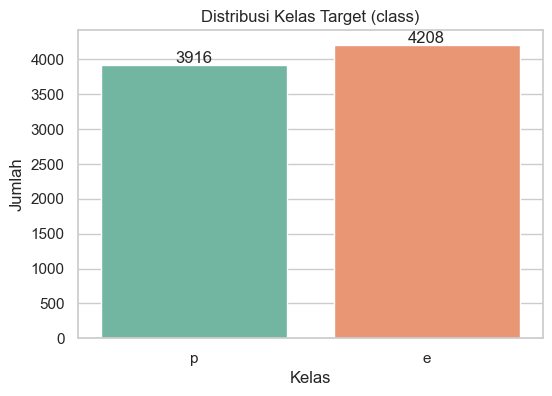

In [26]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

print("jumlah frekuensi")
print(df['class'].value_counts())

print("\nproporsi (%)")
print(df['class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='class', palette='Set2')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.title('Distribusi Kelas Target (class)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [27]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
modus_stalk = df['stalk-root'].mode()[0]
df['stalk-root'] = df['stalk-root'].fillna(modus_stalk)
print(f"modus stalk-root: '{modus_stalk}'")
print(f"missing sekarang: {df['stalk-root'].isnull().sum()}")

modus stalk-root: 'b'
missing sekarang: 0


In [28]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
single_cols = [c for c in df.columns if df[c].nunique() == 1]
df = df.drop(columns=single_cols)
print(f"kolom yang di drop: {single_cols}")
print(f"shape setelah drop: {df.shape}")

kolom yang di drop: ['veil-type']
shape setelah drop: (8124, 22)


In [29]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=['class'])
y = (df['class'] == 'p').astype(int)

print("Distribusi target setelah encoding:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\ntrain size: {X_train.shape[0]} | test size: {X_test.shape[0]}")
print(f"train: {dict(y_train.value_counts())}")
print(f"test: {dict(y_test.value_counts())}")

Distribusi target setelah encoding:
class
0    4208
1    3916
Name: count, dtype: int64

train size: 6499 | test size: 1625
train: {0: np.int64(3366), 1: np.int64(3133)}
test: {0: np.int64(842), 1: np.int64(783)}


In [30]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_ord = oe.fit_transform(X_train)
X_test_ord  = oe.transform(X_test)

print(pd.DataFrame(X_train_ord[:5, :5], columns=X_train.columns[:5]).to_string())

   cap-shape  cap-surface  cap-color  bruises  odor
0        2.0          3.0        9.0      0.0   2.0
1        5.0          2.0        5.0      1.0   5.0
2        0.0          2.0        3.0      0.0   5.0
3        2.0          2.0        4.0      0.0   7.0
4        3.0          3.0        4.0      0.0   2.0


In [31]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe  = ohe.transform(X_test)

print(f"Shape setelah OHE - Train: {X_train_ohe.shape} | Test: {X_test_ohe.shape}")
print(f"Jumlah fitur setelah OHE: {X_train_ohe.shape[1]} (vs {X_train.shape[1]} asli)")

Shape setelah OHE - Train: (6499, 115) | Test: (1625, 115)
Jumlah fitur setelah OHE: 115 (vs 21 asli)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [32]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
cnb = CategoricalNB()
cnb.fit(X_train_ord, y_train)
print(f"jumlah kelas: {cnb.class_count_}")

jumlah kelas: [3366. 3133.]


In [33]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cnb = cnb.predict(X_test_ord)
y_prob_cnb = cnb.predict_proba(X_test_ord)[:, 1]
print(f"Contoh probabilitas 5 sampel pertama: {y_prob_cnb[:5].round(4)}")

Contoh probabilitas 5 sampel pertama: [1.     0.4498 0.     1.     1.    ]


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [34]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bnb = BernoulliNB()
bnb.fit(X_train_ohe, y_train)

BernoulliNB()

In [35]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bnb = bnb.predict(X_test_ohe)
y_prob_bnb = bnb.predict_proba(X_test_ohe)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [36]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
mnb = MultinomialNB()
mnb.fit(X_train_ohe, y_train)

MultinomialNB()

In [37]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_mnb = mnb.predict(X_test_ohe)
y_prob_mnb = mnb.predict_proba(X_test_ohe)[:, 1]

# 4. Evaluasi Model

In [38]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
results = {}
for name, yp, ypr in [('CategoricalNB', y_pred_cnb, y_prob_cnb),
                       ('BernoulliNB',   y_pred_bnb, y_prob_bnb),
                       ('MultinomialNB', y_pred_mnb, y_prob_mnb)]:
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall':    round(recall_score(y_test, yp), 4),
        'F1-Score':  round(f1_score(y_test, yp), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, ypr), 4),
    }

df_results = pd.DataFrame(results).T
print("=== Tabel Perbandingan Metrik Evaluasi ===")
display(df_results)

=== Tabel Perbandingan Metrik Evaluasi ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
CategoricalNB,0.9471,0.9888,0.9004,0.9425,0.9974
BernoulliNB,0.9335,0.9828,0.8774,0.9271,0.9955
MultinomialNB,0.9471,0.9888,0.9004,0.9425,0.9974


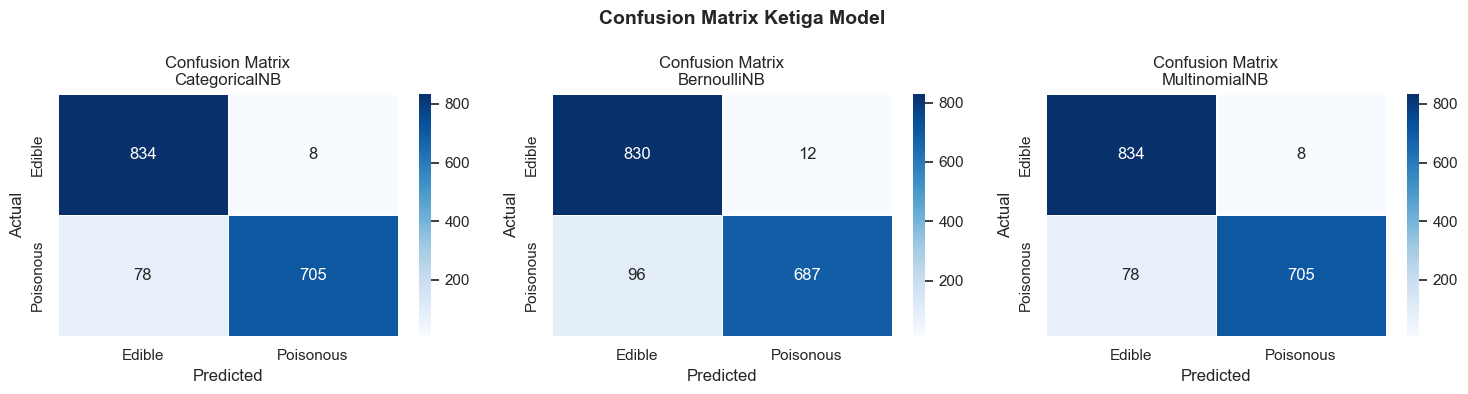

In [39]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, yp) in zip(axes, [('CategoricalNB', y_pred_cnb),
                                   ('BernoulliNB',   y_pred_bnb),
                                   ('MultinomialNB', y_pred_mnb)]):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Edible', 'Poisonous'],
                yticklabels=['Edible', 'Poisonous'],
                linewidths=0.5)
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Ketiga Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

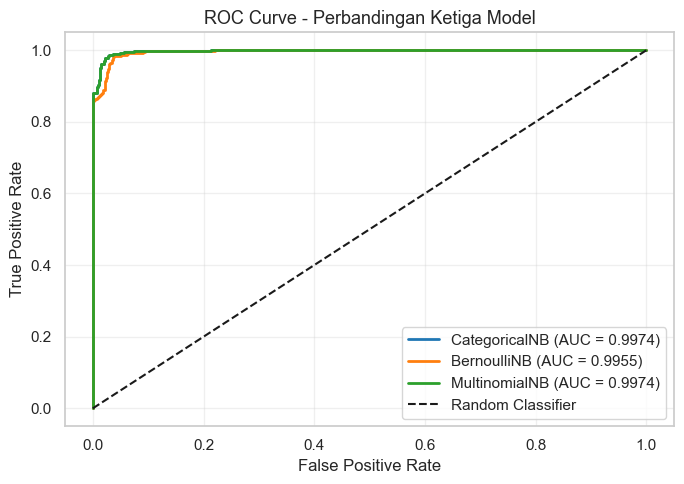

In [40]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for (name, ypr), color in zip([('CategoricalNB', y_prob_cnb),
                                ('BernoulliNB',   y_prob_bnb),
                                ('MultinomialNB', y_prob_mnb)], colors):
    fpr, tpr, _ = roc_curve(y_test, ypr)
    auc = roc_auc_score(y_test, ypr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Perbandingan Ketiga Model', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Berdasarkan hasil eksperimen, diperoleh hasil evaluasi dari ketiga model sebagai berikut:

| Model | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
| --- | --- | --- | --- | --- | --- |
| CategoricalNB | 0.9471 | 0.9888 | 0.9004 | 0.9425 | 0.9974 |
| BernoulliNB | 0.9335 | 0.9828 | 0.8774 | 0.9271 | 0.9955 |
| MultinomialNB | 0.9471 | 0.9888 | 0.9004 | 0.9425 | 0.9974 |

### CategoricalNB vs BernoulliNB vs MultinomialNB
Dari hasil tersebut, CategoricalNB dan MultinomialNB memiliki performa yang sama, dengan Accuracy sebesar 94.71%, F1-Score sebesar 94.25%, dan AUC-ROC sebesar 99.74%. Hasil yang sama ini dapat terjadi karena data yang digunakan sudah melalui proses OneHotEncoder. Setelah proses tersebut, setiap data hanya memiliki satu nilai 1 pada masing-masing kelompok fitur kategorikal. Kondisi ini membuat MultinomialNB memberikan hasil yang sangat mirip dengan CategoricalNB pada dataset ini.

Sementara itu, BernoulliNB menghasilkan performa yang sedikit lebih rendah, yaitu Accuracy 93.35% dan F1-Score 92.71%. Walaupun menggunakan representasi data yang sama, BernoulliNB memiliki cara perhitungan yang berbeda. Model ini ikut mempertimbangkan nilai 0 sebagai informasi penting, sedangkan MultinomialNB lebih berfokus pada keberadaan fitur.

Pada data yang sudah diubah menggunakan OneHotEncoder, nilai 0 sebenarnya hanya menunjukkan bahwa suatu data tidak termasuk dalam kategori tertentu. Nilai tersebut bukan berarti fitur tersebut benar-benar tidak ada. Hal ini kemungkinan membuat BernoulliNB kurang cocok dibandingkan CategoricalNB dan MultinomialNB untuk representasi data seperti ini.

### Precision vs Recall
Ketiga model memiliki nilai Precision yang sangat tinggi. CategoricalNB dan MultinomialNB mencapai 98.88%, sedangkan BernoulliNB mencapai 98.28%. Namun, nilai Recall masih berada di bawah Precision, yaitu sekitar 90.04% untuk CategoricalNB dan MultinomialNB serta 87.74% untuk BernoulliNB.

Hal ini menunjukkan bahwa model cukup jarang memberikan prediksi poisonous ketika jamur sebenarnya edible. Namun, masih terdapat beberapa jamur poisonous yang diprediksi sebagai edible. Kesalahan seperti ini termasuk false negative.

Dalam kasus klasifikasi jamur, false negative perlu mendapat perhatian lebih karena jamur poisonous yang dianggap edible dapat menimbulkan risiko keracunan. Oleh karena itu, jika model akan digunakan untuk tujuan yang lebih mengutamakan keamanan, Recall untuk kelas poisonous dapat menjadi salah satu hal yang perlu ditingkatkan.

### AUC-ROC
Nilai AUC-ROC dari ketiga model juga sangat tinggi. CategoricalNB dan MultinomialNB mendapatkan nilai 0.9974, sedangkan BernoulliNB mendapatkan 0.9955. Nilai yang mendekati 1 menunjukkan bahwa ketiga model memiliki kemampuan yang sangat baik dalam membedakan jamur edible dan poisonous.

Hasil ini juga cukup masuk akal karena dataset Mushroom memiliki beberapa fitur yang sangat membantu dalam membedakan kedua kelas. Salah satunya adalah fitur `odor`, yang memiliki hubungan kuat dengan kategori edible dan poisonous.



# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan
Berdasarkan hasil eksperimen, ketiga model Naive Bayes mampu mengklasifikasikan jamur edible dan poisonous dengan performa yang sangat baik, dengan Accuracy minimal sebesar 93%.

CategoricalNB menjadi pilihan yang paling sesuai secara teori untuk data yang seluruh fiturnya bersifat kategorikal karena model ini memang dirancang untuk menangani fitur kategorikal. Menariknya, pada eksperimen ini hasil CategoricalNB sama dengan MultinomialNB setelah data melalui proses OneHotEncoder.

BernoulliNB memiliki performa sedikit lebih rendah. Salah satu kemungkinan penyebabnya adalah model ini memperlakukan nilai 0 pada hasil OneHotEncoder sebagai informasi yang penting, padahal pada data kategorikal nilai tersebut hanya menunjukkan bahwa data tidak berada pada kategori tertentu.

Selain itu, fitur `stalk-root` memiliki 2.480 missing value atau sekitar 30.5% dari keseluruhan data. Missing value tersebut ditangani menggunakan imputasi modus. Sementara itu, fitur `veil-type` dihapus karena hanya memiliki satu kategori sehingga tidak memberikan informasi yang berarti bagi proses klasifikasi.

### Saran
Beberapa hal yang dapat dicoba pada eksperimen berikutnya adalah:
1. **Threshold adjustment**
Karena kesalahan false negative cukup penting dalam klasifikasi jamur, threshold dapat disesuaikan untuk mencoba meningkatkan Recall pada kelas poisonous. Misalnya, threshold dapat diuji pada nilai 0.3 sampai 0.4 dan dibandingkan dengan hasil menggunakan threshold 0.5.

2. **Feature selection**
Eksperimen dapat dilakukan dengan hanya menggunakan fitur yang paling berpengaruh, seperti `odor`, `spore-print-color`, dan `gill-size`. Tujuannya untuk melihat apakah model yang lebih sederhana masih dapat memberikan performa yang hampir sama.

3. **Penanganan missing value**
Selain menggunakan modus, nilai `?` pada `stalk-root` dapat dianggap sebagai kategori tersendiri, misalnya `unknown`. Hasilnya kemudian dapat dibandingkan dengan metode imputasi modus untuk melihat metode mana yang memberikan performa lebih baik.

4. **Mencoba model lain**
Model seperti Decision Tree dan Random Forest dapat digunakan sebagai pembanding. Dengan begitu, dapat dilihat apakah model berbasis pohon dapat memberikan hasil yang lebih baik dibandingkan ketiga model Naive Bayes.
